# EDA 08 - Revenue Autocorrelation and Lag Analysis

This notebook analyzes autocorrelation and lag relationships in daily revenue using `sales.csv`. The results are exploratory signals for feature engineering and forecasting, not formal time-series modeling conclusions.

## 1. Setup and file discovery

Locate `sales.csv` recursively from the current working directory and configure common analysis settings. No EDA outputs are saved to separate files.

In [1]:
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 220)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path(os.getcwd())
SALES_FILENAME = "sales.csv"
REQUESTED_MAX_LAG = 365
SELECTED_LAGS = [1, 7, 14, 30, 60, 90, 180, 365]
WEEKLY_LAGS = [7, 14, 21, 28]
MONTHLY_LIKE_LAGS = [30, 60, 90]
YEARLY_LAGS = [364, 365, 366]

analysis_ready = False
warning_messages = []
daily = pd.DataFrame()
daily_continuous = pd.DataFrame()
acf_df = pd.DataFrame()
selected_lag_df = pd.DataFrame()
cycle_check_df = pd.DataFrame()
pacf_approx_df = pd.DataFrame()
lag_feature_preview = pd.DataFrame()

lag_1_statement = "Not evaluated."
weekly_cycle_statement = "Not evaluated."
monthly_cycle_statement = "Not evaluated."
yearly_cycle_statement = "Not evaluated."
pacf_statement = "Not evaluated."
missing_date_statement = "Not evaluated."
strongest_lag_candidates = []
recommended_lag_features = []
stationarity_cautions = []


def money_formatter(value, _position=None):
    if pd.isna(value):
        return ""
    abs_value = abs(value)
    if abs_value >= 1_000_000_000:
        return f"{value / 1_000_000_000:,.1f}B"
    if abs_value >= 1_000_000:
        return f"{value / 1_000_000:,.1f}M"
    if abs_value >= 1_000:
        return f"{value / 1_000:,.0f}K"
    return f"{value:,.0f}"


currency_axis = FuncFormatter(money_formatter)

sales_matches = sorted(PROJECT_ROOT.rglob(SALES_FILENAME), key=lambda p: (len(p.parts), str(p).lower()))
sales_path = sales_matches[0] if sales_matches else None

file_discovery_df = pd.DataFrame([{
    "file": SALES_FILENAME,
    "found": sales_path is not None,
    "path": str(sales_path.relative_to(PROJECT_ROOT)) if sales_path else None,
    "match_count": len(sales_matches),
}])

if sales_path is None:
    warning_messages.append("sales.csv was not found under the current working directory.")

print(f"Project root: {PROJECT_ROOT}")
display(file_discovery_df)
if len(sales_matches) > 1:
    display(pd.DataFrame({"matched_paths": [str(p.relative_to(PROJECT_ROOT)) for p in sales_matches]}))

Project root: D:\Code\Datathon 2026


,file,found,path,match_count
0,sales.csv,True,datathon-2026-round-1\sales.csv,1


## 2. Load sales data

Load the sales file safely with pandas. If loading fails, downstream sections display warnings and skip analysis rather than crashing.

In [2]:
sales_raw = None
load_error = None

if sales_path is None:
    load_error = "sales.csv was not found."
else:
    try:
        sales_raw = pd.read_csv(sales_path, low_memory=False)
    except Exception as exc:
        load_error = repr(exc)
        warning_messages.append(f"Could not load sales.csv: {load_error}")

if sales_raw is None:
    load_summary_df = pd.DataFrame([{
        "file": SALES_FILENAME,
        "loaded": False,
        "rows": np.nan,
        "columns": np.nan,
        "error": load_error,
    }])
else:
    load_summary_df = pd.DataFrame([{
        "file": SALES_FILENAME,
        "loaded": True,
        "rows": len(sales_raw),
        "columns": len(sales_raw.columns),
        "error": "",
    }])

display(load_summary_df)
if sales_raw is not None:
    display(sales_raw.head())

,file,loaded,rows,columns,error
0,sales.csv,True,3833,3,


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


## 3. Identify date and revenue columns

Detect the most likely date and revenue columns using normalized column names, date parse success, numeric parse success, and revenue-related naming hints. If a direct revenue column is unavailable, numeric columns are scored as possible revenue proxies.

In [3]:
def normalize_name(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")


def non_empty_mask(series):
    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        return series.astype("string").str.strip().ne("") & series.notna()
    return series.notna()


def numeric_series(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    cleaned = (
        series.astype("string")
        .str.strip()
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace(r"^\((.*)\)$", r"-\1", regex=True)
    )
    return pd.to_numeric(cleaned, errors="coerce")


def parse_datetime_series(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return pd.to_datetime(series, errors="coerce")
    return pd.to_datetime(series, errors="coerce")


def date_score(column_name, series):
    name = normalize_name(column_name)
    name_tokens = set(name.split("_"))
    exact_date_names = {"date", "ds", "day", "sales_date", "order_date", "transaction_date", "created_at", "timestamp"}
    date_terms = {"date", "day", "time", "timestamp", "datetime"}

    name_points = 0
    if name in exact_date_names:
        name_points += 5
    elif name_tokens & date_terms or any(term in name for term in ["date", "timestamp", "datetime"]):
        name_points += 3

    if pd.api.types.is_numeric_dtype(series) and name_points == 0:
        return {
            "column": column_name,
            "normalized_name": name,
            "date_score": -5.0,
            "date_parse_success": 0.0,
            "plausible_date_share": 0.0,
            "non_empty_values": int(non_empty_mask(series).sum()),
        }

    parsed = parse_datetime_series(series)
    mask = non_empty_mask(series)
    non_empty = int(mask.sum())
    parsed_valid = parsed[mask].notna() if non_empty else pd.Series(dtype=bool)
    parse_success = float(parsed_valid.mean()) if non_empty else 0.0

    parsed_non_null = parsed[mask].dropna()
    if len(parsed_non_null):
        plausible = parsed_non_null.between(pd.Timestamp("1990-01-01"), pd.Timestamp("2100-12-31"))
        plausible_share = float(plausible.mean())
        unique_dates = int(parsed_non_null.dt.normalize().nunique())
    else:
        plausible_share = 0.0
        unique_dates = 0

    score = name_points + (3 * parse_success) + (2 * plausible_share) + min(unique_dates / 20, 1)
    return {
        "column": column_name,
        "normalized_name": name,
        "date_score": round(score, 4),
        "date_parse_success": round(parse_success, 4),
        "plausible_date_share": round(plausible_share, 4),
        "non_empty_values": non_empty,
    }


def revenue_score(column_name, series):
    name = normalize_name(column_name)
    name_tokens = set(name.split("_"))
    positive_terms = {
        "revenue": 7,
        "sales": 5,
        "sale": 4,
        "amount": 4,
        "total": 3,
        "value": 2,
        "gmv": 5,
        "turnover": 5,
        "net": 2,
        "gross": 2,
    }
    negative_terms = {
        "id": 6,
        "key": 5,
        "code": 4,
        "date": 6,
        "time": 5,
        "year": 4,
        "month": 4,
        "day": 4,
        "qty": 5,
        "quantity": 5,
        "count": 4,
        "cost": 4,
        "cogs": 5,
        "price": 2,
        "rate": 3,
        "percent": 4,
        "percentage": 4,
    }

    name_points = 0
    for term, points in positive_terms.items():
        if term in name_tokens or term in name:
            name_points += points

    penalty = 0
    for term, points in negative_terms.items():
        if term in name_tokens or term in name:
            penalty += points

    numeric = numeric_series(series)
    mask = non_empty_mask(series)
    non_empty = int(mask.sum())
    numeric_non_null = int(numeric[mask].notna().sum()) if non_empty else 0
    numeric_success = numeric_non_null / non_empty if non_empty else 0.0
    numeric_valid = numeric[mask].dropna()

    if len(numeric_valid):
        positive_share = float((numeric_valid > 0).mean())
        nonzero_share = float((numeric_valid != 0).mean())
        mean_value = float(numeric_valid.mean())
        std_value = float(numeric_valid.std(ddof=1)) if len(numeric_valid) > 1 else 0.0
        abs_median = float(numeric_valid.abs().median())
    else:
        positive_share = 0.0
        nonzero_share = 0.0
        mean_value = np.nan
        std_value = np.nan
        abs_median = 0.0

    variability_points = 1.0 if pd.notna(std_value) and std_value > 0 else 0.0
    magnitude_points = min(np.log10(abs_median + 1) / 4, 1.5) if abs_median > 0 else 0.0
    score = name_points - penalty + (3 * numeric_success) + positive_share + nonzero_share + variability_points + magnitude_points

    return {
        "column": column_name,
        "normalized_name": name,
        "revenue_score": round(float(score), 4),
        "numeric_parse_success": round(float(numeric_success), 4),
        "positive_share": round(float(positive_share), 4),
        "non_empty_values": non_empty,
        "numeric_values": numeric_non_null,
        "mean_numeric_value": mean_value,
        "std_numeric_value": std_value,
        "has_revenue_name_hint": any(term in name for term in ["revenue", "sales", "amount", "gmv", "turnover"]),
    }


if sales_raw is None or sales_raw.empty:
    date_col = None
    revenue_col = None
    parsed_date = None
    parsed_revenue = None
    date_candidates_df = pd.DataFrame()
    revenue_candidates_df = pd.DataFrame()
    column_detection_df = pd.DataFrame([{"warning": "sales.csv was not loaded or is empty."}])
    warning_messages.append("Column detection skipped because sales.csv was not loaded or is empty.")
else:
    date_candidates_df = pd.DataFrame([date_score(col, sales_raw[col]) for col in sales_raw.columns])
    revenue_candidates_df = pd.DataFrame([revenue_score(col, sales_raw[col]) for col in sales_raw.columns])

    date_candidates_df = date_candidates_df.sort_values(["date_score", "date_parse_success", "plausible_date_share"], ascending=False)
    revenue_candidates_df = revenue_candidates_df.sort_values(["revenue_score", "numeric_parse_success", "positive_share"], ascending=False)

    selected_date = date_candidates_df.iloc[0] if len(date_candidates_df) else None
    selected_revenue = revenue_candidates_df.iloc[0] if len(revenue_candidates_df) else None

    date_col = None
    revenue_col = None
    if selected_date is not None and selected_date["date_parse_success"] >= 0.50 and selected_date["plausible_date_share"] >= 0.50:
        date_col = selected_date["column"]

    if selected_revenue is not None and selected_revenue["numeric_parse_success"] >= 0.75 and selected_revenue["revenue_score"] >= 2.0:
        revenue_col = selected_revenue["column"]

    parsed_date = parse_datetime_series(sales_raw[date_col]) if date_col else None
    parsed_revenue = numeric_series(sales_raw[revenue_col]) if revenue_col else None

    if date_col is None:
        warning_messages.append("No usable date column was found. Autocorrelation EDA cannot be completed.")
    if revenue_col is None:
        warning_messages.append("No usable revenue or revenue-like numeric column was found. Autocorrelation EDA cannot be completed.")
    elif not bool(selected_revenue["has_revenue_name_hint"]):
        warning_messages.append(f"Revenue column was inferred from numeric data rather than a direct revenue name: {revenue_col}.")

    column_detection_df = pd.DataFrame([{
        "selected_date_column": date_col,
        "selected_revenue_column": revenue_col,
        "date_parse_success": float(parsed_date.notna().mean()) if parsed_date is not None else np.nan,
        "revenue_numeric_success": float(parsed_revenue.notna().mean()) if parsed_revenue is not None else np.nan,
        "revenue_inferred_without_name_hint": bool(revenue_col and not bool(selected_revenue["has_revenue_name_hint"])),
    }])

print("Selected columns")
display(column_detection_df)
if len(date_candidates_df):
    print("Date candidates")
    display(date_candidates_df)
if len(revenue_candidates_df):
    print("Revenue candidates")
    display(revenue_candidates_df)

Selected columns


,selected_date_column,selected_revenue_column,date_parse_success,revenue_numeric_success,revenue_inferred_without_name_hint
0,Date,Revenue,1.0,1.0,False


Date candidates


,column,normalized_name,date_score,date_parse_success,plausible_date_share,non_empty_values
0,Date,date,11.0,1.0,1.0,3833
1,Revenue,revenue,-5.0,0.0,0.0,3833
2,COGS,cogs,-5.0,0.0,0.0,3833


Revenue candidates


,column,normalized_name,revenue_score,numeric_parse_success,positive_share,non_empty_values,numeric_values,mean_numeric_value,std_numeric_value,has_revenue_name_hint
1,Revenue,revenue,14.5,1.0,1.0,3833,3833,4.286584e+06,2.624840e+06,True
2,COGS,cogs,2.5,1.0,1.0,3833,3833,3.695134e+06,2.219789e+06,False
0,Date,date,-6.0,0.0,0.0,3833,0,NaN,NaN,False


## 4. Prepare daily revenue time series

Parse dates and revenue, aggregate multiple rows per date by summing revenue, sort by date, and create a continuous daily index for lag analysis.

In [4]:
if sales_raw is None or date_col is None or revenue_col is None:
    analysis_ready = False
    prep_summary_df = pd.DataFrame([{"ready": False, "warning": "Missing loaded data, date column, or revenue column."}])
    display(prep_summary_df)
else:
    work = pd.DataFrame({
        "date_raw": sales_raw[date_col],
        "revenue_raw": sales_raw[revenue_col],
        "date": parsed_date,
        "revenue": parsed_revenue,
    })
    work["date"] = pd.to_datetime(work["date"], errors="coerce").dt.normalize()

    initial_rows = len(work)
    invalid_date_rows = int(work["date"].isna().sum())
    invalid_revenue_rows = int(work["revenue"].isna().sum())
    work = work.dropna(subset=["date", "revenue"]).copy()

    if work.empty:
        analysis_ready = False
        warning_messages.append("No rows remained after dropping invalid dates or revenue values.")
        prep_summary_df = pd.DataFrame([{
            "ready": False,
            "initial_rows": initial_rows,
            "invalid_date_rows": invalid_date_rows,
            "invalid_revenue_rows": invalid_revenue_rows,
            "usable_rows": 0,
        }])
        display(prep_summary_df)
    else:
        duplicate_date_rows = int(work.duplicated("date", keep=False).sum())
        daily = (
            work.groupby("date", as_index=False)
            .agg(revenue=("revenue", "sum"), source_rows=("revenue", "size"))
            .sort_values("date")
            .reset_index(drop=True)
        )

        full_calendar = pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")
        daily_continuous = (
            daily.set_index("date")
            .reindex(full_calendar)
            .rename_axis("date")
            .reset_index()
        )
        daily_continuous["was_observed"] = daily_continuous["revenue"].notna()
        daily_continuous["source_rows"] = daily_continuous["source_rows"].fillna(0).astype(int)
        daily_continuous["day_index"] = np.arange(len(daily_continuous))

        observed_dates = pd.DatetimeIndex(daily["date"])
        missing_dates = full_calendar.difference(observed_dates)
        inferred_frequency = pd.infer_freq(observed_dates) if len(observed_dates) >= 3 else None
        median_gap_days = float(daily["date"].diff().dt.days.dropna().median()) if len(daily) > 1 else np.nan

        analysis_ready = True
        if duplicate_date_rows:
            warning_messages.append(f"Found {duplicate_date_rows:,} source rows on dates with duplicates; revenue was aggregated by date using sum.")
        if len(missing_dates):
            warning_messages.append(f"Found {len(missing_dates):,} missing calendar dates between the first and last observed sales dates.")
        if pd.notna(median_gap_days) and median_gap_days > 1:
            warning_messages.append(f"Observed dates are not contiguous daily records; median gap is {median_gap_days:.1f} days.")

        prep_summary_df = pd.DataFrame([{
            "ready": True,
            "initial_rows": initial_rows,
            "invalid_date_rows": invalid_date_rows,
            "invalid_revenue_rows": invalid_revenue_rows,
            "usable_source_rows": len(work),
            "daily_observed_rows_after_aggregation": len(daily),
            "continuous_calendar_rows": len(daily_continuous),
            "duplicate_date_source_rows": duplicate_date_rows,
            "first_date": daily["date"].min().date(),
            "last_date": daily["date"].max().date(),
            "missing_calendar_days": len(missing_dates),
            "inferred_observed_frequency": inferred_frequency,
            "median_gap_days": median_gap_days,
        }])
        display(prep_summary_df)
        display(daily_continuous.head(10))

,ready,initial_rows,invalid_date_rows,invalid_revenue_rows,usable_source_rows,daily_observed_rows_after_aggregation,continuous_calendar_rows,duplicate_date_source_rows,first_date,last_date,missing_calendar_days,inferred_observed_frequency,median_gap_days
0,True,3833,0,0,3833,3833,3833,0,2012-07-04,2022-12-31,0,D,1.0


,date,revenue,source_rows,was_observed,day_index
0,2012-07-04,5123547.94,1,True,0
1,2012-07-05,2751773.45,1,True,1
2,2012-07-06,3054029.42,1,True,2
3,2012-07-07,2667930.94,1,True,3
4,2012-07-08,2360851.90,1,True,4
5,2012-07-09,3548386.46,1,True,5
6,2012-07-10,5234938.62,1,True,6
7,2012-07-11,5582884.78,1,True,7
8,2012-07-12,5734632.02,1,True,8
9,2012-07-13,5309511.71,1,True,9


## 5. Missing date handling for autocorrelation

Autocorrelation is computed on a continuous daily calendar. Missing dates are left as missing instead of filled with zero or interpolation. Each lag correlation uses pairwise-complete observed values only, so a lag is calculated from dates where both today's revenue and the lagged revenue are present.

In [5]:
if not analysis_ready:
    print("WARNING: Skipping missing-date handling summary because usable daily revenue data is not available.")
else:
    missing_date_rows = daily_continuous.loc[~daily_continuous["was_observed"], ["date"]].copy()
    missing_date_statement = (
        "No missing calendar dates were found; autocorrelation uses the observed daily revenue series directly."
        if missing_date_rows.empty
        else f"{len(missing_date_rows):,} missing calendar dates were found and left as NaN; lag correlations use pairwise-complete observations."
    )
    print(missing_date_statement)
    if not missing_date_rows.empty:
        display(missing_date_rows.head(30))

    missing_handling_df = pd.DataFrame([{
        "continuous_daily_index_created": True,
        "missing_dates_filled_with_zero": False,
        "missing_dates_interpolated": False,
        "missing_dates_left_as_nan": True,
        "lag_correlation_method": "pairwise complete observed pairs",
        "reason": "Avoid injecting artificial revenue values into autocorrelation estimates.",
    }])
    display(missing_handling_df)

No missing calendar dates were found; autocorrelation uses the observed daily revenue series directly.


,continuous_daily_index_created,missing_dates_filled_with_zero,missing_dates_interpolated,missing_dates_left_as_nan,lag_correlation_method,reason
0,True,False,False,True,pairwise complete observed pairs,Avoid injecting artificial revenue values into autocorrelation estimates.


## 6. Autocorrelation analysis

Compute an ACF-style correlation for lags from 1 to 365 days where enough data exists. Selected lags are highlighted for short-term, weekly, monthly-like, and yearly seasonality checks.

,lag,autocorrelation,n_pairs,interpretation
0,1,0.865494,3832,strong positive
1,7,0.492042,3826,moderate positive
2,14,0.496429,3819,moderate positive
3,30,0.652300,3803,moderate positive
4,60,0.500018,3773,moderate positive
5,90,0.327666,3743,weak positive
6,180,-0.044186,3653,very weak negative
7,365,0.789784,3468,strong positive


Strongest positive lag correlations


,lag,autocorrelation,n_pairs
0,1,0.865494,3832
364,365,0.789784,3468
363,364,0.748311,3469
1,2,0.735113,3831
362,363,0.654918,3470
29,30,0.652300,3803
28,29,0.641301,3804
334,335,0.627014,3498
2,3,0.621556,3830
30,31,0.619435,3802


Strongest negative lag correlations


,lag,autocorrelation,n_pairs
189,190,-0.188971,3643
190,191,-0.188825,3642
175,176,-0.185262,3657
174,175,-0.184834,3658
188,189,-0.184005,3644
173,174,-0.181603,3659
191,192,-0.177599,3641
172,173,-0.169976,3660
176,177,-0.168027,3656
192,193,-0.164043,3640


Top local ACF peaks


,lag,autocorrelation,n_pairs
29,30,0.652300,3803
334,335,0.627014,3498
60,61,0.542798,3772
13,14,0.496429,3819
6,7,0.492042,3826
303,304,0.489994,3529
20,21,0.436866,3812
349,350,0.420528,3483
356,357,0.408247,3476
343,344,0.373347,3489


Lag-1 autocorrelation is 0.865 (strong positive).


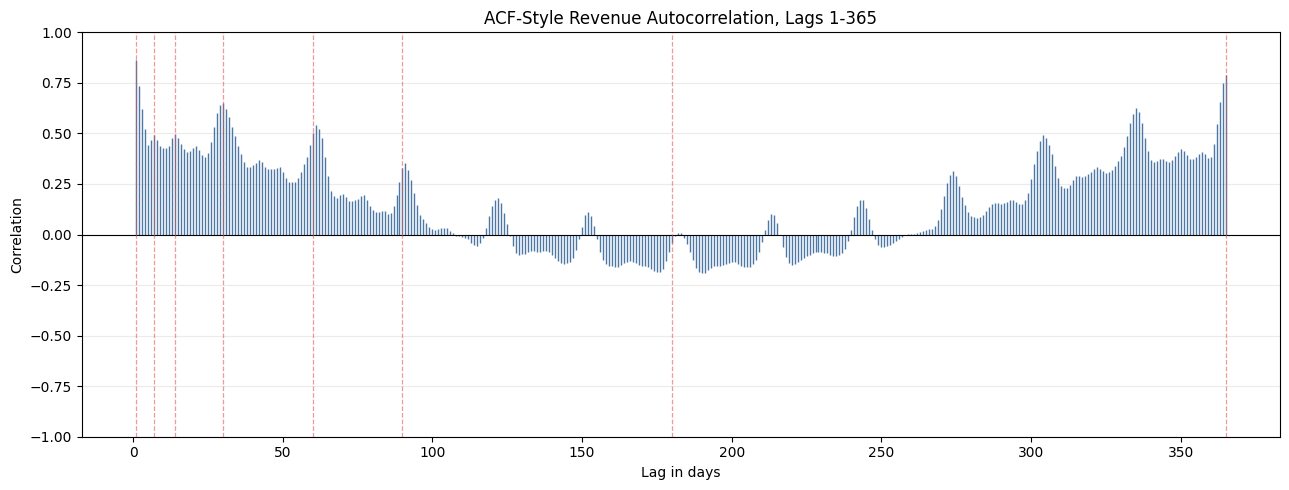

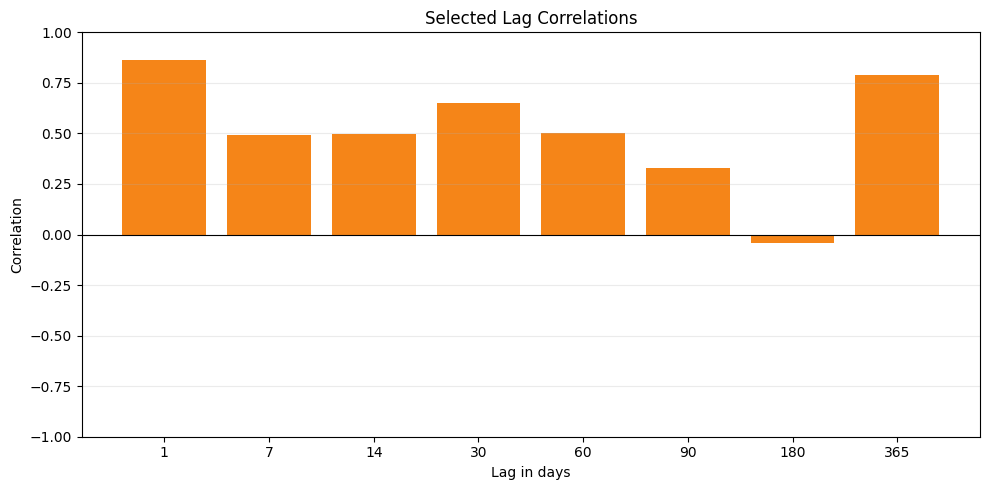

In [6]:
def correlation_at_lag(series, lag, min_pairs=3):
    pair = pd.DataFrame({
        "current": series,
        "lagged": series.shift(lag),
    }).dropna()
    n_pairs = len(pair)
    if n_pairs < min_pairs:
        return np.nan, n_pairs
    if pair["current"].std(ddof=1) == 0 or pair["lagged"].std(ddof=1) == 0:
        return np.nan, n_pairs
    return float(pair["current"].corr(pair["lagged"])), n_pairs


def classify_corr(value):
    if pd.isna(value):
        return "not available"
    abs_value = abs(value)
    if abs_value >= 0.70:
        strength = "strong"
    elif abs_value >= 0.40:
        strength = "moderate"
    elif abs_value >= 0.20:
        strength = "weak"
    else:
        strength = "very weak"
    direction = "positive" if value > 0 else "negative" if value < 0 else "zero"
    return f"{strength} {direction}"


if not analysis_ready:
    print("WARNING: Skipping autocorrelation analysis because usable daily revenue data is not available.")
else:
    revenue_series = daily_continuous.set_index("date")["revenue"].astype(float)
    max_possible_lag = max(0, len(revenue_series) - 1)
    max_lag = min(REQUESTED_MAX_LAG, max_possible_lag)

    if max_lag < 1:
        warning_messages.append("Time series is too short for autocorrelation analysis.")
        acf_df = pd.DataFrame(columns=["lag", "autocorrelation", "n_pairs"])
        selected_lag_df = pd.DataFrame({"lag": SELECTED_LAGS, "autocorrelation": np.nan, "n_pairs": 0})
        display(selected_lag_df)
    else:
        acf_rows = []
        for lag in range(1, max_lag + 1):
            corr, n_pairs = correlation_at_lag(revenue_series, lag)
            acf_rows.append({"lag": lag, "autocorrelation": corr, "n_pairs": n_pairs})
        acf_df = pd.DataFrame(acf_rows)

        selected_rows = []
        for lag in SELECTED_LAGS:
            if lag <= max_lag:
                match = acf_df.loc[acf_df["lag"] == lag].iloc[0]
                selected_rows.append({
                    "lag": lag,
                    "autocorrelation": match["autocorrelation"],
                    "n_pairs": int(match["n_pairs"]),
                    "interpretation": classify_corr(match["autocorrelation"]),
                })
            else:
                selected_rows.append({
                    "lag": lag,
                    "autocorrelation": np.nan,
                    "n_pairs": 0,
                    "interpretation": "not enough data",
                })
        selected_lag_df = pd.DataFrame(selected_rows)

        valid_acf = acf_df.dropna(subset=["autocorrelation"]).copy()
        strongest_positive_lags_df = valid_acf.sort_values("autocorrelation", ascending=False).head(15)
        strongest_negative_lags_df = valid_acf.sort_values("autocorrelation", ascending=True).head(15)

        acf_df["previous_corr"] = acf_df["autocorrelation"].shift(1)
        acf_df["next_corr"] = acf_df["autocorrelation"].shift(-1)
        local_peaks_df = (
            acf_df.loc[
                acf_df["autocorrelation"].notna()
                & (acf_df["autocorrelation"] > acf_df["previous_corr"])
                & (acf_df["autocorrelation"] > acf_df["next_corr"]),
                ["lag", "autocorrelation", "n_pairs"],
            ]
            .sort_values("autocorrelation", ascending=False)
            .head(20)
        )

        lag_1_corr = selected_lag_df.loc[selected_lag_df["lag"] == 1, "autocorrelation"].iloc[0]
        lag_1_statement = f"Lag-1 autocorrelation is {lag_1_corr:.3f} ({classify_corr(lag_1_corr)})." if pd.notna(lag_1_corr) else "Lag-1 autocorrelation is not available."

        candidate_pool = valid_acf.loc[valid_acf["autocorrelation"] > 0].copy()
        candidate_pool["abs_autocorrelation"] = candidate_pool["autocorrelation"].abs()
        strongest_lag_candidates = candidate_pool.sort_values("abs_autocorrelation", ascending=False).head(12)["lag"].astype(int).tolist()
        recommended_lag_features = [lag for lag in SELECTED_LAGS if lag <= max_lag]
        for lag in strongest_lag_candidates[:5]:
            if lag not in recommended_lag_features:
                recommended_lag_features.append(lag)
        recommended_lag_features = sorted(set(recommended_lag_features), key=lambda x: (x not in SELECTED_LAGS, x))

        display(selected_lag_df)
        print("Strongest positive lag correlations")
        display(strongest_positive_lags_df)
        print("Strongest negative lag correlations")
        display(strongest_negative_lags_df)
        print("Top local ACF peaks")
        display(local_peaks_df)
        print(lag_1_statement)

        fig, ax = plt.subplots(figsize=(13, 5))
        ax.vlines(acf_df["lag"], 0, acf_df["autocorrelation"], color="#4C78A8", linewidth=1)
        ax.axhline(0, color="black", linewidth=0.8)
        for lag in SELECTED_LAGS:
            if lag <= max_lag:
                ax.axvline(lag, color="#E45756", linestyle="--", linewidth=0.9, alpha=0.6)
        ax.set_title(f"ACF-Style Revenue Autocorrelation, Lags 1-{max_lag}")
        ax.set_xlabel("Lag in days")
        ax.set_ylabel("Correlation")
        ax.set_ylim(-1, 1)
        ax.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()

        plot_df = selected_lag_df.copy()
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(plot_df["lag"].astype(str), plot_df["autocorrelation"], color="#F58518")
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title("Selected Lag Correlations")
        ax.set_xlabel("Lag in days")
        ax.set_ylabel("Correlation")
        ax.set_ylim(-1, 1)
        ax.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()

## 7. Weekly, monthly-like, and yearly cycle checks

Inspect selected lags around 7-day, 30-day, and 365-day cycles. These checks are exploratory and should be interpreted alongside trend, outliers, missing dates, and model validation.

In [7]:
def lag_subset_table(lags, label):
    rows = []
    if acf_df.empty:
        for lag in lags:
            rows.append({"cycle_group": label, "lag": lag, "autocorrelation": np.nan, "n_pairs": 0, "interpretation": "not available"})
    else:
        max_lag_available = int(acf_df["lag"].max()) if len(acf_df) else 0
        for lag in lags:
            if lag <= max_lag_available and lag in set(acf_df["lag"]):
                row = acf_df.loc[acf_df["lag"] == lag].iloc[0]
                rows.append({
                    "cycle_group": label,
                    "lag": lag,
                    "autocorrelation": row["autocorrelation"],
                    "n_pairs": int(row["n_pairs"]),
                    "interpretation": classify_corr(row["autocorrelation"]),
                })
            else:
                rows.append({"cycle_group": label, "lag": lag, "autocorrelation": np.nan, "n_pairs": 0, "interpretation": "not enough data"})
    return pd.DataFrame(rows)


def cycle_statement_from_values(name, values, strong_threshold=0.40, weak_threshold=0.20):
    valid = pd.Series(values).dropna()
    if valid.empty:
        return f"{name} cycle could not be evaluated because the required lags are not available."
    max_corr = valid.max()
    mean_corr = valid.mean()
    if max_corr >= strong_threshold and mean_corr >= weak_threshold:
        return f"{name} cycle appears visible: max correlation {max_corr:.3f}, mean checked-lag correlation {mean_corr:.3f}."
    if max_corr >= weak_threshold:
        return f"{name} cycle appears weak or mixed: max correlation {max_corr:.3f}, mean checked-lag correlation {mean_corr:.3f}."
    return f"{name} cycle is not clearly visible from these checked lags: max correlation {max_corr:.3f}, mean checked-lag correlation {mean_corr:.3f}."


if not analysis_ready or acf_df.empty:
    print("WARNING: Skipping cycle checks because autocorrelation values are not available.")
else:
    weekly_df = lag_subset_table(WEEKLY_LAGS, "weekly")
    monthly_df = lag_subset_table(MONTHLY_LIKE_LAGS, "monthly_like")
    yearly_df = lag_subset_table(YEARLY_LAGS, "yearly")
    cycle_check_df = pd.concat([weekly_df, monthly_df, yearly_df], ignore_index=True)

    weekly_cycle_statement = cycle_statement_from_values("7-day weekly", weekly_df["autocorrelation"])
    monthly_cycle_statement = cycle_statement_from_values("30-day monthly-like", monthly_df["autocorrelation"])
    yearly_cycle_statement = cycle_statement_from_values("365-day yearly", yearly_df["autocorrelation"])

    display(cycle_check_df)
    print(weekly_cycle_statement)
    print(monthly_cycle_statement)
    print(yearly_cycle_statement)

    cycle_summary_df = pd.DataFrame([
        {
            "cycle": "weekly",
            "checked_lags": ", ".join(map(str, WEEKLY_LAGS)),
            "max_correlation": weekly_df["autocorrelation"].max(skipna=True),
            "mean_correlation": weekly_df["autocorrelation"].mean(skipna=True),
        },
        {
            "cycle": "monthly_like",
            "checked_lags": ", ".join(map(str, MONTHLY_LIKE_LAGS)),
            "max_correlation": monthly_df["autocorrelation"].max(skipna=True),
            "mean_correlation": monthly_df["autocorrelation"].mean(skipna=True),
        },
        {
            "cycle": "yearly",
            "checked_lags": ", ".join(map(str, YEARLY_LAGS)),
            "max_correlation": yearly_df["autocorrelation"].max(skipna=True),
            "mean_correlation": yearly_df["autocorrelation"].mean(skipna=True),
        },
    ])
    print("Cycle summary")
    display(cycle_summary_df)

,cycle_group,lag,autocorrelation,n_pairs,interpretation
0,weekly,7,0.492042,3826,moderate positive
1,weekly,14,0.496429,3819,moderate positive
2,weekly,21,0.436866,3812,moderate positive
3,weekly,28,0.603399,3805,moderate positive
4,monthly_like,30,0.652300,3803,moderate positive
5,monthly_like,60,0.500018,3773,moderate positive
6,monthly_like,90,0.327666,3743,weak positive
7,yearly,364,0.748311,3469,strong positive
8,yearly,365,0.789784,3468,strong positive
9,yearly,366,NaN,0,not enough data


7-day weekly cycle appears visible: max correlation 0.603, mean checked-lag correlation 0.507.
30-day monthly-like cycle appears visible: max correlation 0.652, mean checked-lag correlation 0.493.
365-day yearly cycle appears visible: max correlation 0.790, mean checked-lag correlation 0.769.
Cycle summary


,cycle,checked_lags,max_correlation,mean_correlation
0,weekly,"7, 14, 21, 28",0.603399,0.507184
1,monthly_like,"30, 60, 90",0.652300,0.493328
2,yearly,"364, 365, 366",0.789784,0.769048


## 8. PACF-style exploration

This section uses an approximate PACF-style residual correlation computed with NumPy least squares. For lag `k`, it correlates the residuals of revenue and lag-`k` revenue after regressing both on intermediate lags 1 through `k-1`. This is exploratory and not a replacement for formal PACF diagnostics.

,lag,approx_partial_correlation,n_pairs
0,1,0.865494,3832
1,2,-0.055988,3831
2,3,-0.007555,3830
3,4,-0.018133,3829
4,5,0.019736,3828
5,6,0.378391,3827
6,7,0.018924,3826
7,8,-0.154205,3825
8,9,-0.024730,3824
9,10,0.139490,3823


Strongest approximate partial-lag signals


,lag,approx_partial_correlation,n_pairs,abs_approx_partial_correlation
0,1,0.865494,3832,0.865494
5,6,0.378391,3827,0.378391
10,11,0.233163,3822,0.233163
25,26,0.165919,3807,0.165919
7,8,-0.154205,3825,0.154205
9,10,0.139490,3823,0.139490
26,27,0.137124,3806,0.137124
58,59,0.125792,3774,0.125792
27,28,0.114330,3805,0.114330
24,25,0.100254,3808,0.100254


Approximate PACF-style residual correlations were computed for lags 1-60; interpret as EDA only.


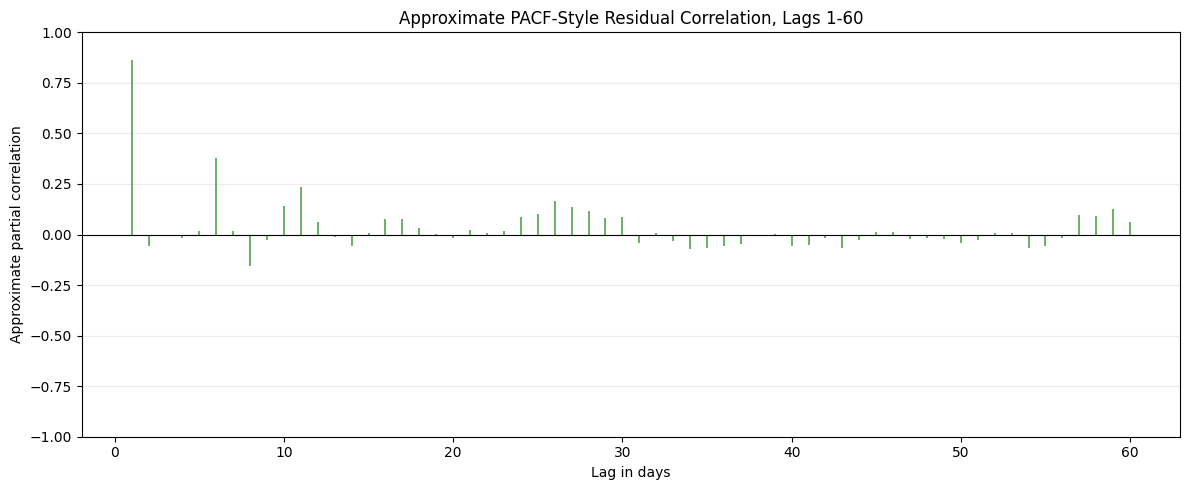

In [8]:
def residualize(target, controls):
    y = np.asarray(target, dtype=float)
    if controls is None or controls.shape[1] == 0:
        return y - np.nanmean(y)
    x = np.asarray(controls, dtype=float)
    x = np.column_stack([np.ones(len(x)), x])
    coef, *_ = np.linalg.lstsq(x, y, rcond=None)
    return y - x @ coef


def approximate_partial_corr(series, lag, min_pairs=20):
    if lag < 1:
        return np.nan, 0

    frame = pd.DataFrame({"current": series, "target_lag": series.shift(lag)})
    for control_lag in range(1, lag):
        frame[f"lag_{control_lag}"] = series.shift(control_lag)
    frame = frame.dropna()
    n_pairs = len(frame)
    min_required = max(min_pairs, lag + 5)
    if n_pairs < min_required:
        return np.nan, n_pairs

    if lag == 1:
        return float(frame["current"].corr(frame["target_lag"])), n_pairs

    controls = frame[[f"lag_{control_lag}" for control_lag in range(1, lag)]].to_numpy(dtype=float)
    current_resid = residualize(frame["current"].to_numpy(dtype=float), controls)
    lag_resid = residualize(frame["target_lag"].to_numpy(dtype=float), controls)
    if np.nanstd(current_resid, ddof=1) == 0 or np.nanstd(lag_resid, ddof=1) == 0:
        return np.nan, n_pairs
    return float(np.corrcoef(current_resid, lag_resid)[0, 1]), n_pairs


if not analysis_ready:
    print("WARNING: Skipping PACF-style exploration because usable daily revenue data is not available.")
else:
    revenue_series = daily_continuous.set_index("date")["revenue"].astype(float)
    max_pacf_lag = min(60, max(0, len(revenue_series) - 2))
    if max_pacf_lag < 1:
        pacf_approx_df = pd.DataFrame(columns=["lag", "approx_partial_correlation", "n_pairs"])
        pacf_statement = "PACF-style exploration skipped because the time series is too short."
        print(pacf_statement)
    else:
        pacf_rows = []
        for lag in range(1, max_pacf_lag + 1):
            corr, n_pairs = approximate_partial_corr(revenue_series, lag)
            pacf_rows.append({"lag": lag, "approx_partial_correlation": corr, "n_pairs": n_pairs})
        pacf_approx_df = pd.DataFrame(pacf_rows)
        pacf_valid = pacf_approx_df.dropna(subset=["approx_partial_correlation"]).copy()
        pacf_valid["abs_approx_partial_correlation"] = pacf_valid["approx_partial_correlation"].abs()
        strongest_pacf_df = pacf_valid.sort_values("abs_approx_partial_correlation", ascending=False).head(15)
        pacf_statement = f"Approximate PACF-style residual correlations were computed for lags 1-{max_pacf_lag}; interpret as EDA only."

        display(pacf_approx_df)
        print("Strongest approximate partial-lag signals")
        display(strongest_pacf_df)
        print(pacf_statement)

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.vlines(pacf_approx_df["lag"], 0, pacf_approx_df["approx_partial_correlation"], color="#54A24B", linewidth=1.2)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(f"Approximate PACF-Style Residual Correlation, Lags 1-{max_pacf_lag}")
        ax.set_xlabel("Lag in days")
        ax.set_ylabel("Approximate partial correlation")
        ax.set_ylim(-1, 1)
        ax.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()

## 9. Lag feature preview

Create candidate lag features using `shift`, so every lagged column contains only past revenue values from the continuous daily calendar. Missing past values remain missing.

,date,revenue,revenue_lag_1,revenue_lag_7,revenue_lag_14,revenue_lag_30,revenue_lag_60,revenue_lag_90,revenue_lag_180,revenue_lag_365
0,2012-07-04,5123547.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,2751773.45,5123547.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-07-06,3054029.42,2751773.45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-07-07,2667930.94,3054029.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-07-08,2360851.90,2667930.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2012-07-09,3548386.46,2360851.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2012-07-10,5234938.62,3548386.46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2012-07-11,5582884.78,5234938.62,5123547.94,NaN,NaN,NaN,NaN,NaN,NaN
8,2012-07-12,5734632.02,5582884.78,2751773.45,NaN,NaN,NaN,NaN,NaN,NaN
9,2012-07-13,5309511.71,5734632.02,3054029.42,NaN,NaN,NaN,NaN,NaN,NaN


Lag features are created with pandas shift on the continuous daily calendar; each value uses only past revenue at the specified lag.


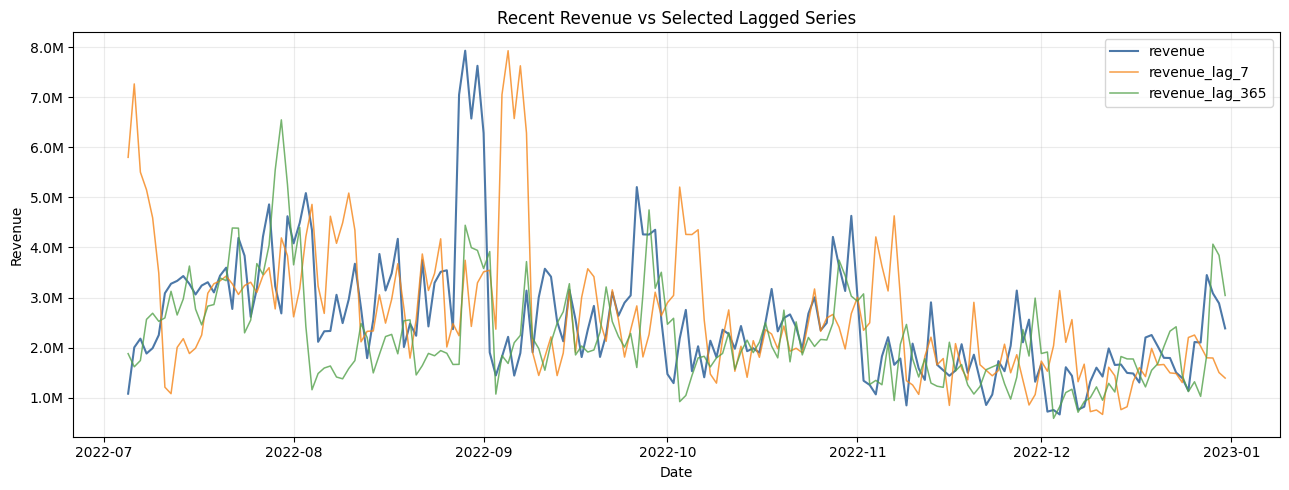

In [9]:
if not analysis_ready:
    print("WARNING: Skipping lag feature preview because usable daily revenue data is not available.")
else:
    lag_features = daily_continuous[["date", "revenue"]].copy()
    for lag in SELECTED_LAGS:
        lag_features[f"revenue_lag_{lag}"] = lag_features["revenue"].shift(lag)

    preview_parts = [lag_features.head(12)]
    longest_lag_col = f"revenue_lag_{max(SELECTED_LAGS)}"
    if longest_lag_col in lag_features.columns:
        later_preview = lag_features.dropna(subset=[longest_lag_col]).head(12)
        if not later_preview.empty:
            preview_parts.append(later_preview)
    lag_feature_preview = pd.concat(preview_parts, ignore_index=False).drop_duplicates(subset=["date"]).sort_values("date").head(24)

    display(lag_feature_preview)
    print("Lag features are created with pandas shift on the continuous daily calendar; each value uses only past revenue at the specified lag.")

    chart_df = lag_features.dropna(subset=["revenue"]).tail(180).copy()
    if len(chart_df) >= 14 and "revenue_lag_7" in chart_df.columns:
        fig, ax = plt.subplots(figsize=(13, 5))
        ax.plot(chart_df["date"], chart_df["revenue"], label="revenue", color="#4C78A8", linewidth=1.5)
        if chart_df["revenue_lag_7"].notna().any():
            ax.plot(chart_df["date"], chart_df["revenue_lag_7"], label="revenue_lag_7", color="#F58518", alpha=0.8, linewidth=1.1)
        if "revenue_lag_365" in chart_df.columns and chart_df["revenue_lag_365"].notna().any():
            ax.plot(chart_df["date"], chart_df["revenue_lag_365"], label="revenue_lag_365", color="#54A24B", alpha=0.8, linewidth=1.1)
        ax.set_title("Recent Revenue vs Selected Lagged Series")
        ax.set_xlabel("Date")
        ax.set_ylabel("Revenue")
        ax.yaxis.set_major_formatter(currency_axis)
        ax.grid(alpha=0.25)
        ax.legend()
        plt.tight_layout()
        plt.show()

## 10. Key observations and warnings

Summarize autocorrelation signals, candidate lag features, and cautions. Autocorrelation can be affected by missing dates, outliers, level shifts, and non-stationary trends, so these findings should be validated in forecasting experiments.

In [10]:
if analysis_ready and not acf_df.empty:
    trend_corr = daily_continuous[["day_index", "revenue"]].dropna()["day_index"].corr(daily_continuous[["day_index", "revenue"]].dropna()["revenue"])
    if pd.notna(trend_corr) and abs(trend_corr) >= 0.30:
        stationarity_cautions.append(f"Revenue has a notable correlation with time index ({trend_corr:.3f}), so trend/non-stationarity may inflate long-lag autocorrelation.")
    if daily_continuous["revenue"].isna().any():
        stationarity_cautions.append("Missing dates were left as NaN; lag estimates use pairwise-complete observations and may vary in sample size by lag.")
    if daily_continuous["revenue"].dropna().skew() > 1.0:
        stationarity_cautions.append("Revenue is right-skewed; outliers may affect correlation estimates.")

    selected_corr_lookup = selected_lag_df.set_index("lag")["autocorrelation"].to_dict() if not selected_lag_df.empty else {}
    lag_1_corr = selected_corr_lookup.get(1, np.nan)
    lag_1_summary = (
        f"yes, lag-1 is {classify_corr(lag_1_corr)} at {lag_1_corr:.3f}"
        if pd.notna(lag_1_corr) and abs(lag_1_corr) >= 0.40
        else f"not strong; lag-1 is {classify_corr(lag_1_corr)} at {lag_1_corr:.3f}" if pd.notna(lag_1_corr)
        else "not available"
    )

    weekly_summary = weekly_cycle_statement
    monthly_summary = monthly_cycle_statement
    yearly_summary = yearly_cycle_statement

    candidate_text = ", ".join(str(lag) for lag in strongest_lag_candidates[:10]) if strongest_lag_candidates else "None"
    recommended_text = ", ".join(f"revenue_lag_{lag}" for lag in recommended_lag_features) if recommended_lag_features else "None"
    caution_text = " ".join(stationarity_cautions) if stationarity_cautions else "No critical missing-date or trend cautions were flagged by the simple checks."

    print("Insight summary")
    print(f"- Strong lag-1 autocorrelation: {lag_1_summary}.")
    print(f"- Weekly cycle: {weekly_summary}")
    print(f"- Monthly-like cycle: {monthly_summary}")
    print(f"- Yearly seasonality: {yearly_summary}")
    print(f"- Strongest useful positive lag candidates: {candidate_text}")
    print(f"- Recommended lag features for forecasting: {recommended_text}")
    print(f"- PACF-style note: {pacf_statement}")
    print(f"- Cautions: {caution_text}")
else:
    print("Insight summary")
    print("- Autocorrelation and lag analysis could not be completed because usable daily revenue data or lag correlations were not available.")

print("\nWarnings and data notes")
if warning_messages:
    for message in dict.fromkeys(warning_messages):
        print(f"- {message}")
else:
    print("- No critical warnings.")

Insight summary
- Strong lag-1 autocorrelation: yes, lag-1 is strong positive at 0.865.
- Weekly cycle: 7-day weekly cycle appears visible: max correlation 0.603, mean checked-lag correlation 0.507.
- Monthly-like cycle: 30-day monthly-like cycle appears visible: max correlation 0.652, mean checked-lag correlation 0.493.
- Yearly seasonality: 365-day yearly cycle appears visible: max correlation 0.790, mean checked-lag correlation 0.769.
- Strongest useful positive lag candidates: 1, 365, 364, 2, 363, 30, 29, 335, 3, 31
- Recommended lag features for forecasting: revenue_lag_1, revenue_lag_7, revenue_lag_14, revenue_lag_30, revenue_lag_60, revenue_lag_90, revenue_lag_180, revenue_lag_365, revenue_lag_2, revenue_lag_363, revenue_lag_364
- PACF-style note: Approximate PACF-style residual correlations were computed for lags 1-60; interpret as EDA only.
- Cautions: Revenue is right-skewed; outliers may affect correlation estimates.

Warnings and data notes
- No critical warnings.
